In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [28]:
df=pd.read_csv('input/house_price.csv')
df

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
...,...,...,...,...,...,...,...,...
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West


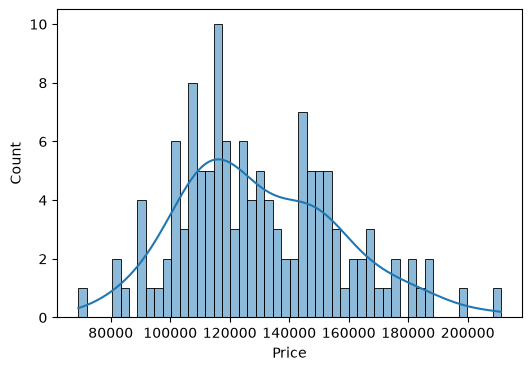

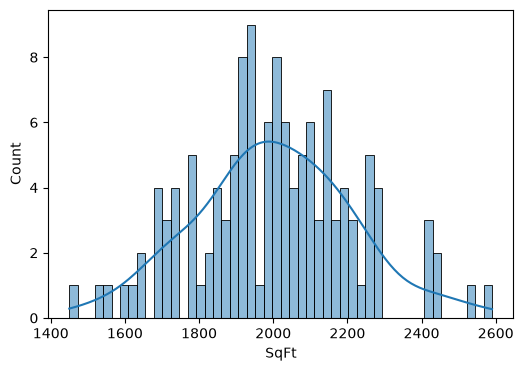

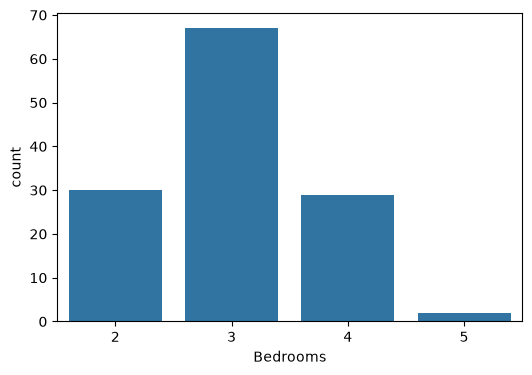

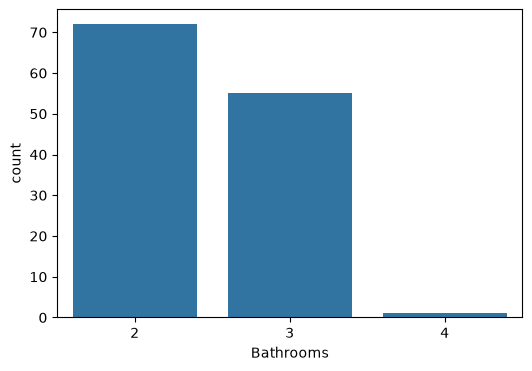

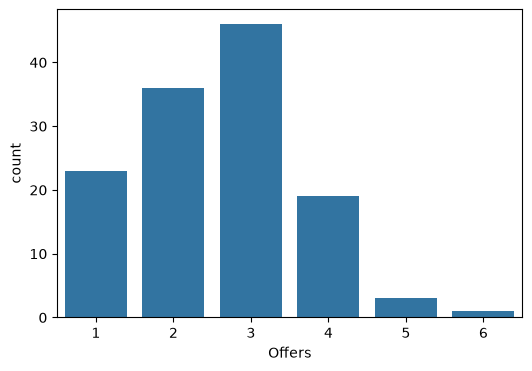

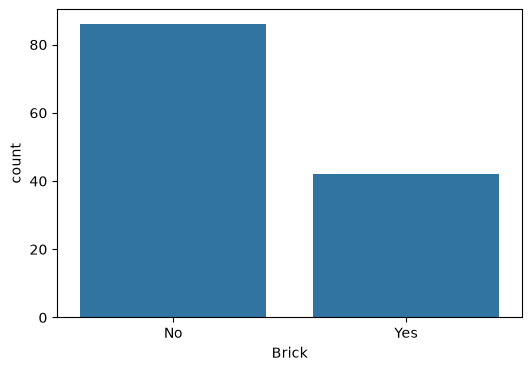

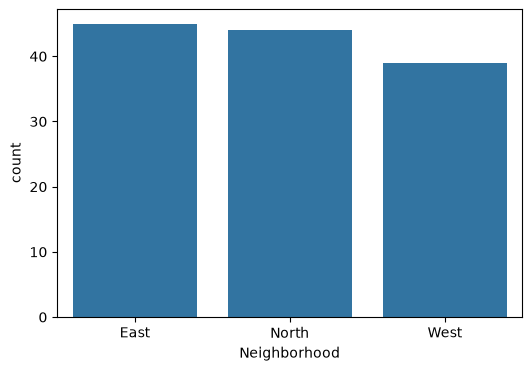

In [29]:
#EDA
numeric_column=['Price','SqFt']
count_column=['Bedrooms','Bathrooms','Offers','Brick','Neighborhood']
for col in numeric_column :
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=50,kde=True)
for col in count_column :
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])

<Axes: >

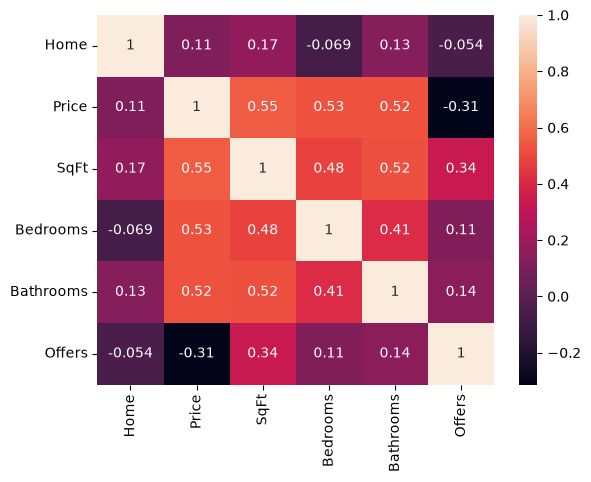

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='SqFt', ylabel='Price'>

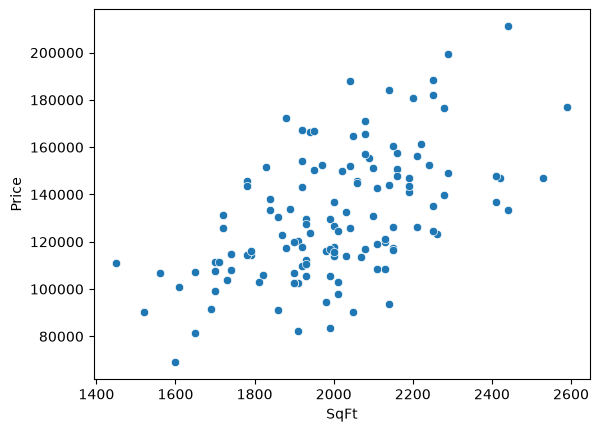

In [31]:
sns.scatterplot(data=df,x='SqFt',y='Price')

In [32]:
df.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [33]:
X =df.drop(columns=['Price','Home'])
y=df['Price']
X

,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1790,2,2,2,No,East
1,2030,4,2,3,No,East
2,1740,3,2,1,No,East
3,1980,3,2,3,No,East
4,2130,3,3,3,No,East
...,...,...,...,...,...,...
123,1900,3,3,3,Yes,East
124,2160,4,3,3,Yes,East
125,2070,2,2,2,No,North
126,2020,3,3,1,No,West


In [34]:
X = pd.get_dummies(X,columns = ['Neighborhood'])

In [35]:

X['Brick'] = X['Brick'].map({"No": 0, "Yes": 1})

In [ ]:
X = X.astype(int)
X

,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood_East,Neighborhood_North,Neighborhood_West
0,1790,2,2,2,0,1,0,0
1,2030,4,2,3,0,1,0,0
2,1740,3,2,1,0,1,0,0
3,1980,3,2,3,0,1,0,0
4,2130,3,3,3,0,1,0,0
...,...,...,...,...,...,...,...,...
123,1900,3,3,3,1,1,0,0
124,2160,4,3,3,1,1,0,0
125,2070,2,2,2,0,0,1,0
126,2020,3,3,1,0,0,0,1


In [37]:
scaler = StandardScaler()
num_features = ['SqFt', 'Bedrooms', 'Bathrooms', 'Offers']
X[num_features] = scaler.fit_transform(X[num_features])

In [40]:
X

,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood_East,Neighborhood_North,Neighborhood_West
0,-1.000916,-1.415327,-0.868939,-0.542769,0,1,0,0
1,0.137904,1.350503,-0.868939,0.396075,0,1,0,0
2,-1.238171,-0.032412,-0.868939,-1.481614,0,1,0,0
3,-0.099350,-0.032412,-0.868939,0.396075,0,1,0,0
4,0.612413,-0.032412,1.082362,0.396075,0,1,0,0
...,...,...,...,...,...,...,...,...
123,-0.478957,-0.032412,1.082362,0.396075,1,1,0,0
124,0.754765,1.350503,1.082362,0.396075,1,1,0,0
125,0.327707,-1.415327,-0.868939,-0.542769,0,0,1,0
126,0.090453,-0.032412,1.082362,-1.481614,0,0,0,1


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
r2 #predict problaty 80%

0.8062934622232132

In [39]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7151374444459018